# Speaker Concept Clustering — Step by Step

This notebook walks through the full pipeline of representing speakers as
**concept vectors** and testing whether those vectors can identify a speaker
from an unseen recording.

**Protocol**: 19 recordings → enrollment vector · 1 held-out recording → test.

We follow **3 example speakers** (`id00012`, `id00016`, `id00018`) through
every step so you can trace exactly how the numbers flow.

> **Caveat**: The TCAV rows were generated with `target_mode=predicted`, so
> concept sensitivities target the model's *predicted* class, not necessarily
> the true speaker.  We still group by `true label`.

In [1]:
from __future__ import annotations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'tcav-v2-quality-tcav_rows.csv').exists():
    REPO_ROOT = REPO_ROOT.parent

rows_df = pd.read_csv(REPO_ROOT / 'tcav-v2-quality-tcav_rows.csv')

SEED = 1337
ENROLL_COUNT = 19
TEST_COUNT = 1
EXAMPLES = ['id00012', 'id00016', 'id00018']

speakers = sorted(rows_df['true label'].unique().tolist())
concepts = sorted(rows_df['concept name'].unique().tolist())

print(f'Speakers:              {len(speakers)}')
print(f'Concepts:              {len(concepts)}')
recs = rows_df.groupby('true label')['path'].nunique().iloc[0]
print(f'Recordings / speaker:  {recs}')
print(f'Total rows:            {len(rows_df):,}')
print()
print(f'Example speakers we will follow: {EXAMPLES}')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:14: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.0)
  from scipy.sparse import csr_matrix, issparse


Speakers:              10
Concepts:              28
Recordings / speaker:  20
Total rows:            44,800

Example speakers we will follow: ['id00012', 'id00016', 'id00018']


## Step 1 — Enrollment / Test Split

Each speaker has **20 recordings**.  We shuffle them with a fixed seed, hold
out **1 recording for testing**, and keep the remaining **19 for enrollment**.

The enrollment recordings build the speaker's *concept fingerprint*.
The single test recording checks whether we can identify the speaker.

In [2]:
enroll_parts, test_parts = [], []
test_recording = {}  # speaker → held-out path

for spk in speakers:
    spk_df = rows_df[rows_df['true label'] == spk]
    paths = sorted(spk_df['path'].dropna().astype(str).unique().tolist())
    shuffled = pd.Series(paths).sample(frac=1.0, random_state=SEED).tolist()

    t_paths = set(shuffled[:TEST_COUNT])
    e_paths = set(shuffled[TEST_COUNT : TEST_COUNT + ENROLL_COUNT])

    test_parts.append(spk_df[spk_df['path'].isin(t_paths)])
    enroll_parts.append(spk_df[spk_df['path'].isin(e_paths)])
    test_recording[spk] = list(t_paths)[0]

enroll_df = pd.concat(enroll_parts, ignore_index=True)
test_df = pd.concat(test_parts, ignore_index=True)

print(f'Enrollment rows: {len(enroll_df):,}    Test rows: {len(test_df):,}')
print()
for spk in EXAMPLES:
    n_e = enroll_df[enroll_df['true label'] == spk]['path'].nunique()
    n_t = test_df[test_df['true label'] == spk]['path'].nunique()
    fname = test_recording[spk].rsplit('/', 1)[-1]
    print(f'  {spk}:  {n_e} enrollment  |  {n_t} test  \u2192  {fname}')

Enrollment rows: 42,560    Test rows: 2,240

  id00012:  19 enrollment  |  1 test  →  00006.m4a
  id00016:  19 enrollment  |  1 test  →  00006.m4a
  id00018:  19 enrollment  |  1 test  →  00006.m4a


## Step 2 — Computing the Enrollment Concept Vector

For each speaker we average `pos_effect_delta` across all **19 enrollment
recordings** and all random baselines, **per concept**, producing a
**28-dimensional vector**.

* **Positive value** → the concept pushes the model *toward* identifying this speaker.
* **Negative value** → the concept pushes the model *away*.

This vector is the speaker's **concept fingerprint**.

Enrollment matrix: 10 speakers × 28 concepts



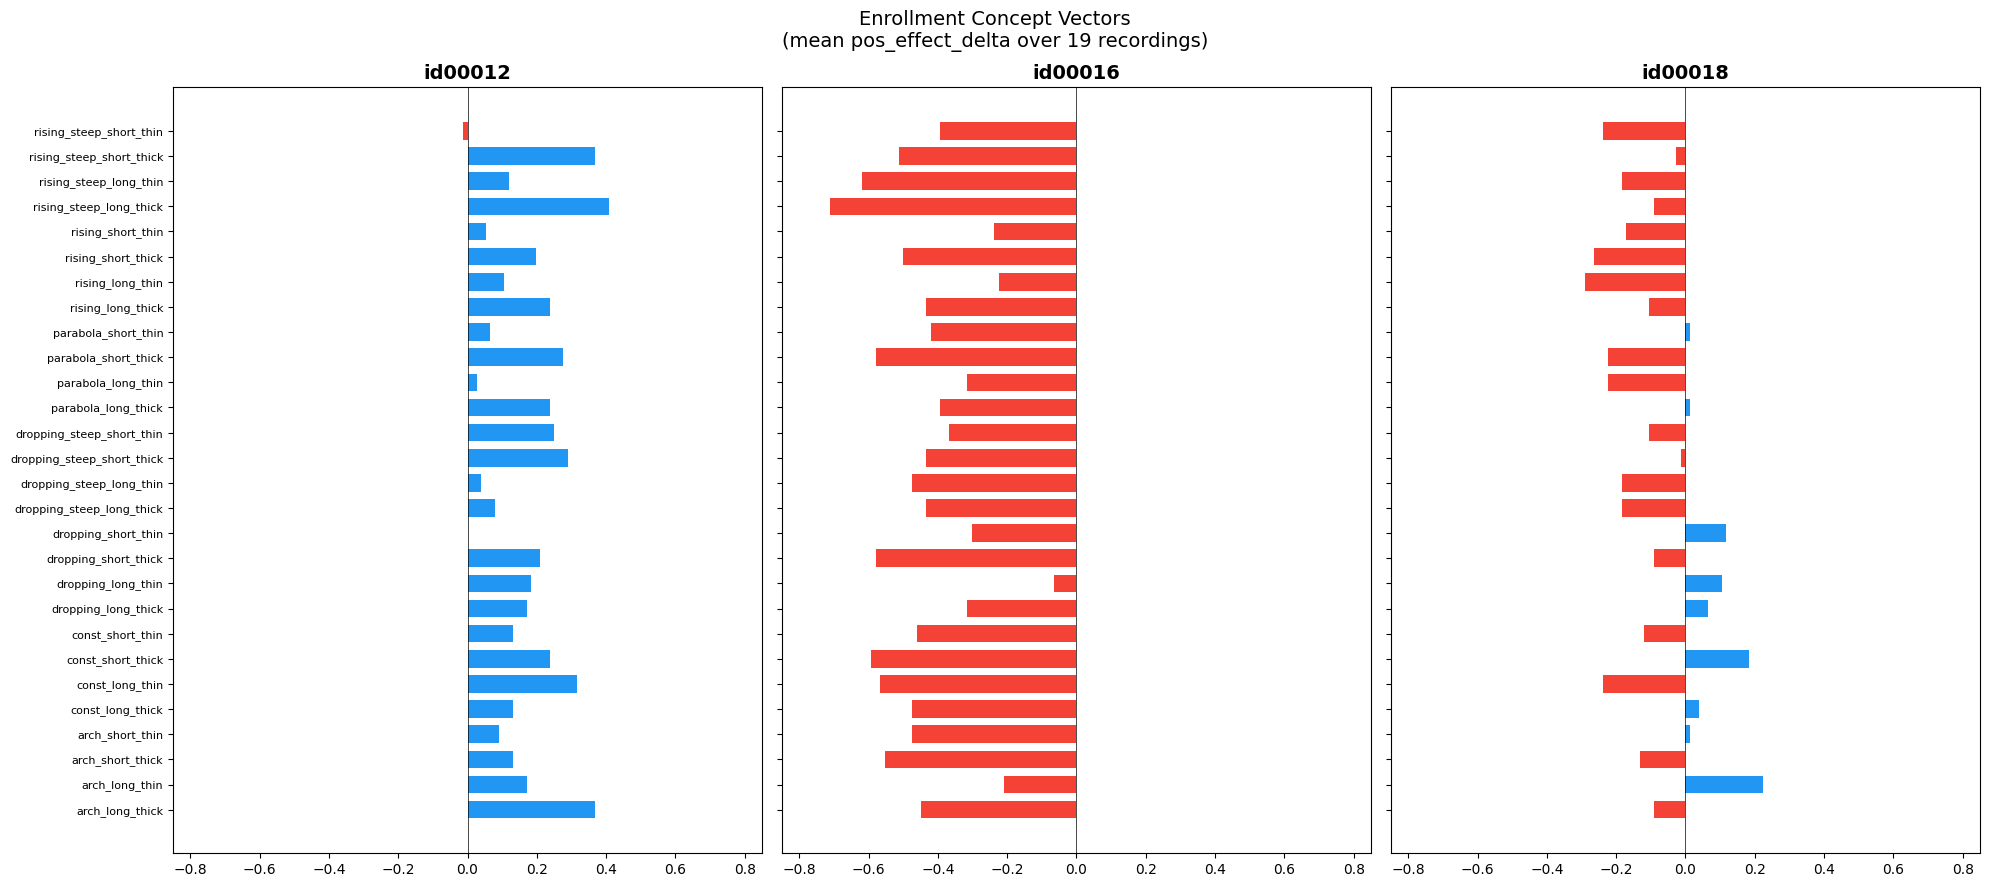

In [3]:
# Average pos_effect_delta per (speaker, concept) across 19 enrollment recordings
enrollment_matrix = (
    enroll_df
    .groupby(['true label', 'concept name'])['pos_effect_delta']
    .mean()
    .unstack(fill_value=0.0)
    .reindex(columns=concepts, fill_value=0.0)
    .sort_index()
)

print(f'Enrollment matrix: {enrollment_matrix.shape[0]} speakers \u00d7 '
      f'{enrollment_matrix.shape[1]} concepts')
print()

# Bar chart for the 3 example speakers
fig, axes = plt.subplots(1, 3, figsize=(20, 9), sharey=True)
for i, (ax, spk) in enumerate(zip(axes, EXAMPLES)):
    vec = enrollment_matrix.loc[spk]
    colors = ['#2196F3' if v >= 0 else '#f44336' for v in vec]
    ax.barh(concepts, vec.values, color=colors, height=0.7)
    ax.set_title(spk, fontsize=14, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlim(-0.85, 0.85)
    ax.tick_params(axis='y', labelsize=8)
fig.suptitle(
    'Enrollment Concept Vectors\n'
    '(mean pos_effect_delta over 19 recordings)',
    fontsize=14,
)
plt.tight_layout()
plt.show()

## Step 3 — Test Recording → Sign Vector

For the **single held-out recording** we compute the same per-concept average,
then collapse each value to a **sign**: **+1** if positive, **−1** otherwise.

The sign vector captures the *direction* of each concept's influence, discarding
magnitude.  It is the "question" we match against each speaker's enrollment
fingerprint.

In [4]:
# Raw concept vector for each speaker's single test recording
test_raw = {}
for spk in speakers:
    spk_test = test_df[test_df['true label'] == spk]
    vec = spk_test.groupby('concept name')['pos_effect_delta'].mean()
    test_raw[spk] = vec.reindex(concepts, fill_value=0.0)

# Convert to sign vectors: +1 if positive, -1 otherwise
test_signs = {}
for spk, vec in test_raw.items():
    test_signs[spk] = vec.apply(lambda x: 1.0 if x > 0 else -1.0)

# Show raw \u2192 sign conversion for the 3 example speakers
for spk in EXAMPLES:
    raw = test_raw[spk]
    signs = test_signs[spk]
    print(f'\n{"=" * 68}')
    print(f'  {spk}  \u2014  test: ...{test_recording[spk].rsplit("/", 1)[-1]}')
    print(f'{"=" * 68}')
    print(f'  {"Concept":30s}  {"Raw":>10s}  \u2192  {"Sign":>5s}')
    print(f'  {"-" * 55}')
    for c in concepts:
        sign_str = '+1' if signs[c] > 0 else '-1'
        print(f'  {c:30s}  {raw[c]:+10.4f}  \u2192  {sign_str:>5s}')


  id00012  —  test: ...00006.m4a
  Concept                                Raw  →   Sign
  -------------------------------------------------------
  arch_long_thick                    +1.0000  →     +1
  arch_long_thin                     +1.0000  →     +1
  arch_short_thick                   +1.0000  →     +1
  arch_short_thin                    +1.0000  →     +1
  const_long_thick                   +1.0000  →     +1
  const_long_thin                    +1.0000  →     +1
  const_short_thick                  +0.7500  →     +1
  const_short_thin                   +1.0000  →     +1
  dropping_long_thick                +1.0000  →     +1
  dropping_long_thin                 +1.0000  →     +1
  dropping_short_thick               +1.0000  →     +1
  dropping_short_thin                +0.7500  →     +1
  dropping_steep_long_thick          +1.0000  →     +1
  dropping_steep_long_thin           +1.0000  →     +1
  dropping_steep_short_thick         +1.0000  →     +1
  dropping_steep_short_thin 

## Step 4 — Scoring: Enrollment Vector × Sign Vector

For each *(test recording, speaker)* pair the score is:

$$\text{score} = \sum_{i=1}^{28} \text{enrollment}_i \times \text{sign}_i$$

**Intuition**: If the enrollment value is positive where the sign is +1 and
negative where the sign is −1, the products are all positive → high score →
good match.  When they disagree the products are negative → low score.

We first walk through the **element-wise multiplication** for one example,
then score all speakers.

In [5]:
def print_scoring_detail(test_spk, enroll_spk):
    enroll_vec = enrollment_matrix.loc[enroll_spk]
    sign_vec = test_signs[test_spk]
    products = enroll_vec * sign_vec

    tag = 'SELF-MATCH' if test_spk == enroll_spk else 'CROSS-SPEAKER'
    print(f'\n  {test_spk} test  \u00d7  {enroll_spk} enrollment   [{tag}]')
    print(f'  {"\u2500" * 66}')
    print(f'  {"Concept":30s} {"Enroll":>8s} \u00d7 {"Sign":>4s} = {"Product":>8s}')
    print(f'  {"\u2500" * 66}')
    for c in concepts:
        e = enroll_vec[c]
        s = sign_vec[c]
        p = products[c]
        sign_str = '+1' if s > 0 else '-1'
        mark = '\u2713' if p > 0 else '\u2717'
        print(f'  {c:30s} {e:+8.4f} \u00d7 {sign_str:>4s} = {p:+8.4f}  {mark}')
    print(f'  {"\u2500" * 66}')
    total = products.sum()
    print(f'  {"TOTAL SCORE":30s} {"":>8s}   {"":>4s}   {total:+8.4f}')
    return total

# Self-match: id00012 test vs id00012 enrollment
score_self = print_scoring_detail(EXAMPLES[0], EXAMPLES[0])

# Cross-speaker: id00012 test vs id00016 enrollment
score_cross = print_scoring_detail(EXAMPLES[0], EXAMPLES[1])

print(f'\n\n  Summary:')
print(f'    Self-match score  ({EXAMPLES[0]} vs {EXAMPLES[0]}): {score_self:+.4f}')
print(f'    Cross-match score ({EXAMPLES[0]} vs {EXAMPLES[1]}): {score_cross:+.4f}')


  id00012 test  ×  id00012 enrollment   [SELF-MATCH]
  ──────────────────────────────────────────────────────────────────
  Concept                          Enroll × Sign =  Product
  ──────────────────────────────────────────────────────────────────
  arch_long_thick                 +0.3684 ×   +1 =  +0.3684  ✓
  arch_long_thin                  +0.1711 ×   +1 =  +0.1711  ✓
  arch_short_thick                +0.1316 ×   +1 =  +0.1316  ✓
  arch_short_thin                 +0.0921 ×   +1 =  +0.0921  ✓
  const_long_thick                +0.1316 ×   +1 =  +0.1316  ✓
  const_long_thin                 +0.3158 ×   +1 =  +0.3158  ✓
  const_short_thick               +0.2368 ×   +1 =  +0.2368  ✓
  const_short_thin                +0.1316 ×   +1 =  +0.1316  ✓
  dropping_long_thick             +0.1711 ×   +1 =  +0.1711  ✓
  dropping_long_thin              +0.1842 ×   +1 =  +0.1842  ✓
  dropping_short_thick            +0.2105 ×   +1 =  +0.2105  ✓
  dropping_short_thin             +0.0000 ×   +1 =  +0.

In [6]:
# Score every test recording against every enrollment vector
score_rows = []
for test_spk in speakers:
    signs = test_signs[test_spk]
    for enroll_spk in speakers:
        score = float((enrollment_matrix.loc[enroll_spk] * signs).sum())
        score_rows.append({
            'test_speaker': test_spk,
            'vs_speaker': enroll_spk,
            'score': score,
        })

scores_df = pd.DataFrame(score_rows)

# Best match per test speaker
best = (
    scores_df.sort_values('score', ascending=False)
    .groupby('test_speaker')
    .first()
    .reset_index()
)
best['correct'] = best['test_speaker'] == best['vs_speaker']

# Show rankings for the 3 example speakers
for test_spk in EXAMPLES:
    ranked = scores_df[scores_df['test_speaker'] == test_spk].sort_values(
        'score', ascending=False,
    )
    top_spk = ranked.iloc[0]['vs_speaker']
    print(f'\n{test_spk} test recording \u2014 scores vs all speakers:')
    for _, row in ranked.iterrows():
        flags = ''
        if row['vs_speaker'] == test_spk:
            flags += ' \u2190 TRUE'
        if row['vs_speaker'] == top_spk:
            flags += ' \u2605 BEST'
        print(f'  vs {row["vs_speaker"]}  {row["score"]:+8.3f}{flags}')


id00012 test recording — scores vs all speakers:
  vs id00025   +18.263 ★ BEST
  vs id00024   +15.092
  vs id00019    +8.579
  vs id00012    +4.882 ← TRUE
  vs id00021    +3.105
  vs id00018    -2.197
  vs id00026    -7.474
  vs id00020    -7.803
  vs id00016   -12.092
  vs id00022   -23.895

id00016 test recording — scores vs all speakers:
  vs id00025   +18.263 ★ BEST
  vs id00024   +15.092
  vs id00019    +8.579
  vs id00012    +4.882
  vs id00021    +3.105
  vs id00018    -2.197
  vs id00026    -7.474
  vs id00020    -7.803
  vs id00016   -12.092 ← TRUE
  vs id00022   -23.895

id00018 test recording — scores vs all speakers:
  vs id00022   +23.895 ★ BEST
  vs id00016   +12.092
  vs id00020    +7.803
  vs id00026    +7.474
  vs id00018    +2.197 ← TRUE
  vs id00021    -3.105
  vs id00012    -4.882
  vs id00019    -8.579
  vs id00024   -15.092
  vs id00025   -18.263


## Step 5 — Full Results & Visualization

We now look at the complete **score matrix**, overall identification
**accuracy**, **K-Means clustering** of enrollment vectors, and a **PCA
scatter** plot.

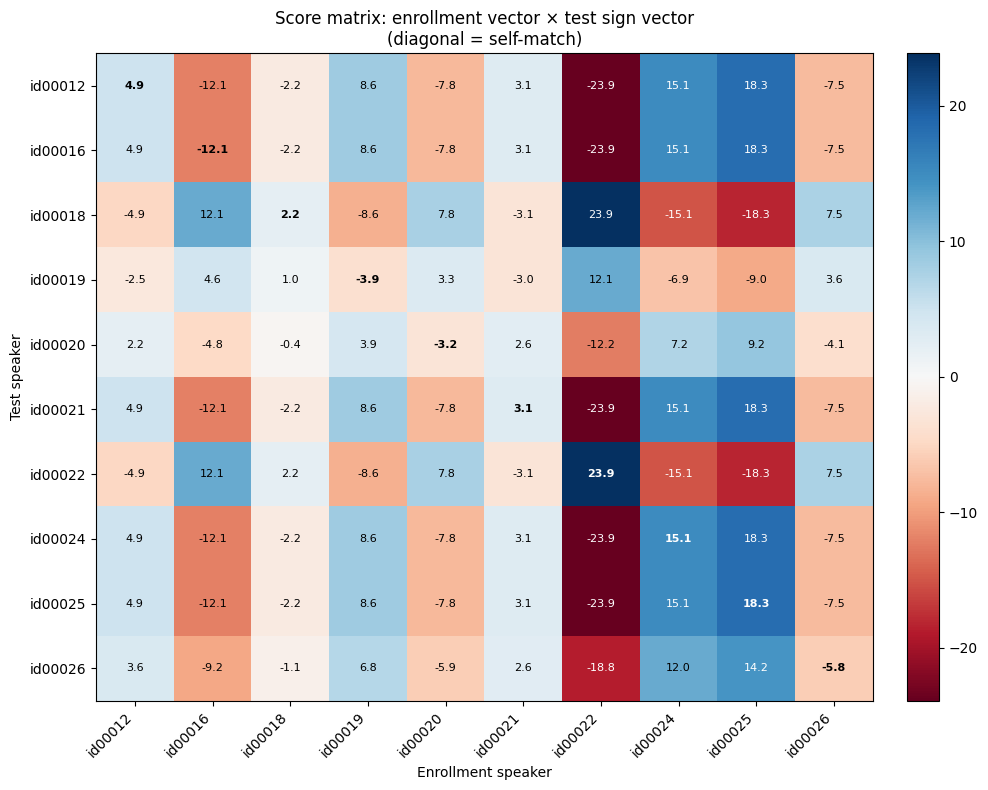

Identification accuracy: 2/10 (20%)

  id00012  →  predicted id00025  ✗
  id00016  →  predicted id00025  ✗
  id00018  →  predicted id00022  ✗
  id00019  →  predicted id00022  ✗
  id00020  →  predicted id00025  ✗
  id00021  →  predicted id00025  ✗
  id00022  →  predicted id00022  ✓
  id00024  →  predicted id00025  ✗
  id00025  →  predicted id00025  ✓
  id00026  →  predicted id00025  ✗


In [7]:
# Score matrix heatmap (rows=test, columns=enrollment)
score_matrix = scores_df.pivot(
    index='test_speaker', columns='vs_speaker', values='score',
).reindex(index=speakers, columns=speakers)

fig, ax = plt.subplots(figsize=(10, 8))
vmax = max(abs(score_matrix.values.min()), abs(score_matrix.values.max()))
im = ax.imshow(score_matrix.values, cmap='RdBu', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(speakers)))
ax.set_yticks(range(len(speakers)))
ax.set_xticklabels(speakers, rotation=45, ha='right')
ax.set_yticklabels(speakers)
ax.set_xlabel('Enrollment speaker')
ax.set_ylabel('Test speaker')
ax.set_title('Score matrix: enrollment vector \u00d7 test sign vector\n(diagonal = self-match)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for i in range(len(speakers)):
    for j in range(len(speakers)):
        v = score_matrix.values[i, j]
        color = 'white' if abs(v) > vmax * 0.55 else 'black'
        weight = 'bold' if i == j else 'normal'
        ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                color=color, fontsize=8, fontweight=weight)
plt.tight_layout()
plt.show()

# Accuracy
n_correct = int(best['correct'].sum())
n_total = len(best)
print(f'Identification accuracy: {n_correct}/{n_total} ({n_correct / n_total:.0%})')
print()
for _, row in best.sort_values('test_speaker').iterrows():
    status = '\u2713' if row['correct'] else '\u2717'
    print(f'  {row["test_speaker"]}  \u2192  predicted {row["vs_speaker"]}  {status}')

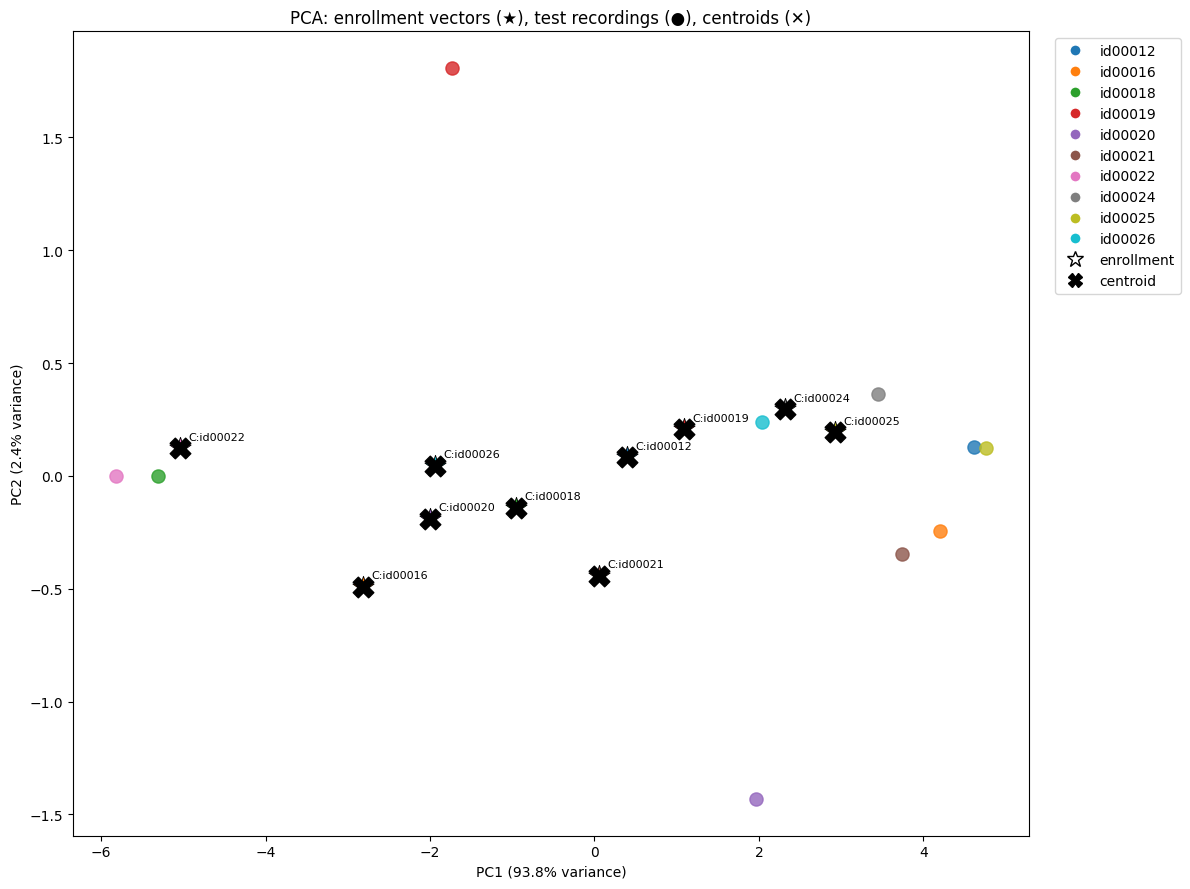

In [8]:
# K-Means clustering on enrollment vectors
n_clusters = len(speakers)
kmeans = KMeans(n_clusters=n_clusters, random_state=SEED, n_init='auto')
cluster_labels = kmeans.fit_predict(enrollment_matrix.values)
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=concepts)

cluster_to_speaker = {}
for spk, lbl in zip(enrollment_matrix.index, cluster_labels):
    cluster_to_speaker[int(lbl)] = str(spk)

# Prepare PCA data
enroll_pca = enrollment_matrix.copy()
enroll_pca['point_type'] = 'enrollment'
enroll_pca['speaker'] = enroll_pca.index.astype(str)
enroll_pca = enroll_pca.reset_index(drop=True)

test_pca = pd.DataFrame(test_raw).T.reindex(columns=concepts, fill_value=0.0)
test_pca['point_type'] = 'test'
test_pca['speaker'] = test_pca.index.astype(str)
test_pca = test_pca.reset_index(drop=True)

cent_pca = centroids.copy()
cent_pca['point_type'] = 'centroid'
cent_pca['speaker'] = [cluster_to_speaker[i] for i in range(n_clusters)]

all_pts = pd.concat([enroll_pca, test_pca, cent_pca], ignore_index=True)

pca = PCA(n_components=2, random_state=SEED)
xy = pca.fit_transform(all_pts[concepts].values)
all_pts['pc1'] = xy[:, 0]
all_pts['pc2'] = xy[:, 1]

# Plot
cmap = {spk: plt.cm.tab10(i % 10) for i, spk in enumerate(speakers)}
fig, ax = plt.subplots(figsize=(12, 9))

for spk in speakers:
    ev = all_pts[(all_pts['point_type'] == 'enrollment') & (all_pts['speaker'] == spk)]
    tv = all_pts[(all_pts['point_type'] == 'test') & (all_pts['speaker'] == spk)]
    ax.scatter(ev['pc1'], ev['pc2'], marker='*', s=260, color=cmap[spk],
               edgecolors='black', linewidths=0.6, zorder=3)
    ax.scatter(tv['pc1'], tv['pc2'], marker='o', s=90, color=cmap[spk],
               alpha=0.8, zorder=2, label=spk)

cv = all_pts[all_pts['point_type'] == 'centroid']
ax.scatter(cv['pc1'], cv['pc2'], marker='X', s=220, color='black', zorder=4)
for _, row in cv.iterrows():
    ax.annotate(f'C:{row["speaker"]}', (row['pc1'], row['pc2']),
                textcoords='offset points', xytext=(6, 6), fontsize=8)

handles = [
    Line2D([0], [0], marker='o', color='w', label=s,
           markerfacecolor=cmap[s], markersize=8)
    for s in speakers
] + [
    Line2D([0], [0], marker='*', color='k', label='enrollment',
           markerfacecolor='w', markersize=12, linewidth=0),
    Line2D([0], [0], marker='X', color='k', label='centroid',
           markerfacecolor='k', markersize=10, linewidth=0),
]
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_title('PCA: enrollment vectors (\u2605), test recordings (\u25cf), centroids (\u2715)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.tight_layout()
plt.show()

In [9]:
summary = {
    'n_speakers': len(speakers),
    'n_concepts': len(concepts),
    'enrollment_recordings': ENROLL_COUNT,
    'test_recordings': TEST_COUNT,
    'identification_accuracy': f'{n_correct}/{n_total} ({n_correct / n_total:.0%})',
    'mean_best_score': round(float(best['score'].mean()), 2),
}

print('Summary')
print('\u2500' * 40)
for k, v in summary.items():
    print(f'  {k}: {v}')

Summary
────────────────────────────────────────
  n_speakers: 10
  n_concepts: 28
  enrollment_recordings: 19
  test_recordings: 1
  identification_accuracy: 2/10 (20%)
  mean_best_score: 17.46
